# Notebook 02 — Métricas iniciales (PSNR / SSIM)

En este cuaderno medimos **PSNR** y **SSIM** entre:

- la imagen **original a color** `I*.jpg`, y
- la imagen **colorizada** `I*_color.png` generada a partir de su versión en gris.

Salida:

- Tabla `../eval/tables/metrics.csv` con PSNR/SSIM por imagen.
- Mosaico `../eval/figs/mosaic_metrics.png` con comparaciones visuales.

In [7]:
from pathlib import Path
import numpy as np
import cv2 as cv
import pandas as pd
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim

BASE = Path('..').resolve()
DATA_RAW = (BASE / 'imgs')
DATA_RES = (BASE / 'imgs_out')
EVAL_T  = BASE / 'eval' / 'tables'
EVAL_F  = BASE / 'eval' / 'figs'

EVAL_T.mkdir(parents=True, exist_ok=True)
EVAL_F.mkdir(parents=True, exist_ok=True)

print('RAW (gt)  =', DATA_RAW)
print('RES (out) =', DATA_RES)
print('TABLAS    =', EVAL_T)
print('FIGURAS   =', EVAL_F)

RAW (gt)  = C:\Users\adria\OneDrive\Escritorio\UNI\PID\Trabajo\PID_colorization\imgs
RES (out) = C:\Users\adria\OneDrive\Escritorio\UNI\PID\Trabajo\PID_colorization\imgs_out
TABLAS    = C:\Users\adria\OneDrive\Escritorio\UNI\PID\Trabajo\PID_colorization\eval\tables
FIGURAS   = C:\Users\adria\OneDrive\Escritorio\UNI\PID\Trabajo\PID_colorization\eval\figs


## Preparación y emparejado de imágenes

Asumimos que el Notebook 01 ya ha generado, para cada `I*.jpg`:

- su versión en gris `I*_gray.jpg` en `../imgs/`,
- su versión colorizada `I*_color.png` en `../imgs_out/`.

En este cuaderno **no modificamos las imágenes**. Solo:

1. Emparejamos cada original `I*.jpg` con su salida `I*_color.*`.
2. Calculamos PSNR y SSIM en color entre ambos.

## Utilidades de carga y emparejado

Definimos funciones auxiliares para leer imágenes en color y
emparejar cada original `I*.jpg` con su correspondiente `I*_color.*`.

In [8]:
def imread_color(path):
    """Lee una imagen en color (BGR)."""
    img = cv.imread(str(path))
    return img  # BGR


def list_pairs():
    """
    Devuelve lista de pares (ruta_gt, ruta_colorizada), emparejando:

    - GT:  ImagenXX.jpg
    - OUT: ImagenXX_color.jpg
    """

    pairs = []

    # 1. Buscar las originales: ImagenXX.jpg
    raw_files = sorted([
        p for p in DATA_RAW.glob("I*")
        if "_gray" not in p.name and "_color" not in p.name and "ansel" not in p.name.lower()
    ])

    for rf in raw_files:
        name = rf.stem  # 'Imagen01'
        color_name = f"{name}_color.jpg"
        color_path = DATA_RES / color_name

        if color_path.exists():
            pairs.append((rf, color_path))
        else:
            print(f"[AVISO] No se encontró {color_name}")

    print(f"Se han emparejado {len(pairs)} imágenes.")
    return pairs

## Cálculo de PSNR y SSIM en color

Para cada par (original, colorizada):

1. Leemos ambas imágenes en color.
2. Ajustamos tamaños si no coinciden.
3. Calculamos PSNR y SSIM **por canal** utilizando las imágenes en color.
4. Guardamos los resultados en `eval/tables/metrics.csv`.

In [9]:
rows = []

pairs = list_pairs()

if not pairs:
    print("No hay pares (GT, colorizada). ¿Has ejecutado el Notebook 01?")
else:
    for raw_p, res_p in pairs:
        gt  = imread_color(raw_p)   # ImagenXX.jpg (BGR)
        out = imread_color(res_p)   # ImagenXX_color.jpg (BGR)

        if gt is None or out is None:
            print(f'[AVISO] No se pudieron leer: {raw_p.name} o {res_p.name}. Se omite.')
            continue

        # Aseguramos que ambas tengan el mismo tamaño
        if gt.shape != out.shape:
            out = cv.resize(out, (gt.shape[1], gt.shape[0]))

        # Convertimos a RGB por claridad
        gt_rgb  = cv.cvtColor(gt, cv.COLOR_BGR2RGB)
        out_rgb = cv.cvtColor(out, cv.COLOR_BGR2RGB)

        # Cálculo de métricas
        psnr_val = psnr(gt_rgb, out_rgb, data_range=255)
        ssim_val = ssim(gt_rgb, out_rgb, data_range=255, channel_axis=-1)

        rows.append({
            'imagen': raw_p.name,  # Ej: Imagen01.jpg
            'psnr': psnr_val,
            'ssim': ssim_val
        })

    # Guardamos y mostramos
    df = pd.DataFrame(rows).sort_values('imagen')
    csv_path = EVAL_T / 'metrics.csv'
    df.to_csv(csv_path, index=False)
    display(df)

Se han emparejado 13 imágenes.


,imagen,psnr,ssim
0,Imagen01.jpg,19.558175,0.818306
1,Imagen02.jpg,18.217422,0.823651
2,Imagen03.jpg,23.781436,0.885787
3,Imagen04.jpg,20.938815,0.924317
4,Imagen05.jpg,16.425632,0.764340
5,Imagen06.jpg,22.386341,0.967275
6,Imagen07.jpg,24.419704,0.930732
7,Imagen08.jpg,18.673125,0.839732
8,Imagen09.jpg,21.526681,0.929275
9,Imagen10.jpg,24.332470,0.981429


## Mosaico antes/después (primeras N imágenes)

Mostramos algunas parejas (original, salida colorizada) para tener una
visualización cualitativa rápida del comportamiento del modelo.

CSV  -> C:\Users\adria\OneDrive\Escritorio\UNI\PID\Trabajo\PID_colorization\eval\tables\metrics.csv
FIG  -> C:\Users\adria\OneDrive\Escritorio\UNI\PID\Trabajo\PID_colorization\eval\figs\mosaic_metrics.png


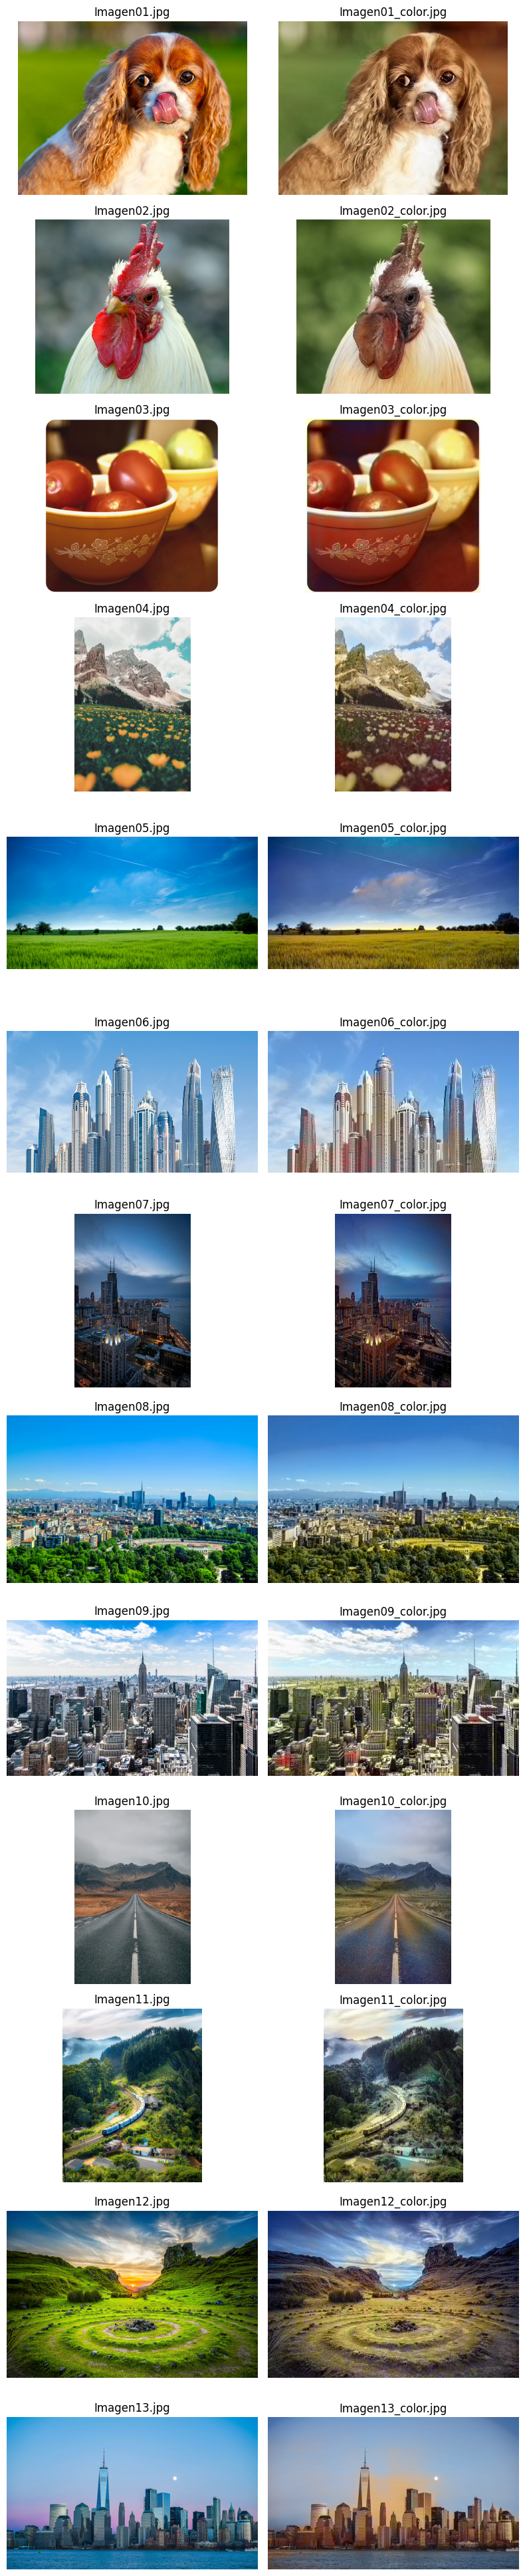

In [4]:
if not pairs:
    print("No hay pares (gt, colorizada). Asegúrate de haber generado las imágenes en imgs_out.")
else:
    N = len(pairs)
    fig, axes = plt.subplots(N, 2, figsize=(8, 3 * N))
    if N == 1:
        axes = np.array([axes])

    for i in range(N):
        raw_p, res_p = pairs[i]
        raw_bgr = cv.imread(str(raw_p))
        res_bgr = cv.imread(str(res_p))

        axes[i, 0].imshow(cv.cvtColor(raw_bgr, cv.COLOR_BGR2RGB)); axes[i, 0].set_title(raw_p.name); axes[i, 0].axis('off')
        axes[i, 1].imshow(cv.cvtColor(res_bgr, cv.COLOR_BGR2RGB)); axes[i, 1].set_title(res_p.name); axes[i, 1].axis('off')

    plt.tight_layout()
    fig_path = EVAL_F / 'mosaic_metrics.png'
    plt.savefig(fig_path, dpi=150)
    print('CSV  ->', csv_path)
    print('FIG  ->', fig_path)